## Reading in Datasets from Kaggle
#### Given the total size of the entire Kaggle Dataset (89GB) capturing 153M QUIC protocol flows *weeks_to_download* variable lets you select which weeks to download

In [1]:
import math

from tensorflow.python.autograph.pyct.templates import replace

from data_acquisition import Data_acquisition

da = Data_acquisition()

# Specify which weeks to be downloaded
weeks_to_download = ['week_1', 'week_2', 'week_3', 'week_4']

da.download_datasets(weeks_to_download)


KeyboardInterrupt



In [1]:
import pandas as pd
import numpy as np

### Data Exploration
#### Given the size only one day of data is explored to examine features and their distributions

In [5]:
week1_mon_df = pd.read_csv('./dataset/week_1/mon.csv')
week1_mon_df.head(5)

FileNotFoundError: [Errno 2] No such file or directory: './dataset/week_1/mon.csv'

In [ ]:
week1_mon_df.info()
week1_mon_df.isnull().sum()

#### Class Distribution

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

app_counts = week1_mon_df['APP'].value_counts()


plt.figure(figsize=(14, 20))
sns.barplot(x=app_counts.values, y=app_counts.index)
plt.xscale('log')
plt.xlabel('Flow Count (in log scale)')
plt.ylabel('App Class')
plt.title('Full APP Class Distribution - Log Scale')
plt.tight_layout()
plt.show()

In [21]:
providers = ['google', 'microsoft', 'facebook','discord', 'instagram', 'apple', 'garmin']
def get_provider(app_name):
    app_lower = str(app_name).lower()
    for provider in providers:
        if provider in app_lower:
            return provider
    return 'other'

app_provider_percentage = (
    app_counts
    .groupby(get_provider)
    .sum()
    .pipe(lambda s: s / s.sum() * 100)
    .round(2)
    .sort_values(ascending=False)
)

plt.figure(figsize=(6, 6))
plt.pie(app_provider_percentage, labels=app_provider_percentage.index, autopct='%1.0f%%')
plt.title('Traffic per Provider')
plt.show()

NameError: name 'app_counts' is not defined

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

category_counts = week1_mon_df['CATEGORY'].value_counts()


plt.figure(figsize=(14, 10))
sns.barplot(x=category_counts.values, y=category_counts.index)
plt.xscale('log')
plt.xlabel('Flow Count (in log scale)')
plt.ylabel('App Class')
plt.title('Category Class Distribution - Log Scale')
plt.tight_layout()
plt.show()

### Dropping Useless Columns prior to Storing in Database to reduce dataset size
#### Cols Dropped and Rational:
##### ID: Identifier column, no predictable signal.
##### SRC_IP/DST_IP: Dropped since although still present post ECH, vary across CDN's and load balancers. Model would memorise IP addresses rather.
##### DST_ASN: Derived from DST_IP and hence is proxy introducing data-leakage.
##### DST_PORT: Consistent, (443) is standard for QUIC.
##### PROTOCOL: Consistent all flows are QUIC-over-UDP.
##### QUIC_VERSION: Extracted from HelloClient Handshake.
##### QUIC_SNI: Extracted from HelloClient Handshake.
##### QUIC_USERAGENT: Derrived from HelloClient Handshake and lots of nulls.
###
#### Cols used for labels
##### APP: Application used (Fine-grained Label)
##### CATEGORY: Type of traffic (Generic Label)

In [1]:
# Drops columns and converts and replaces .csv files with .parquet to increase efficiency and decrease storage requirements
import json

cols_to_drop = []

cols_to_drop= ['ID', 'SRC_IP', 'DST_IP', 'DST_ASN', 'SRC_PORT', 'DST_PORT', 'PROTOCOL', 'QUIC_VERSION', 'QUIC_SNI', 'QUIC_USERAGENT']
with open('./config.json', 'w') as f:
    json.dump({'cols_to_drop': cols_to_drop}, f, indent=4)

# Ran as script due to multiprocessing
!python preprocessing.py

In [3]:
import pandas as pd

from feature_engineering import Feature_Engineering

week_1 = pd.read_parquet('./dataset/week_1/mon.parquet')
week_1 = week_1.head(500)

week_1.to_csv('./pre_processing_df.csv', index=True)

ppi_pad_len = 30
phist_pad_len = 8

fe = Feature_Engineering(week_1)
week_1 = fe.parse_col('PPI', ['PPI_TIMES', 'PPI_DIRS', 'PPI_SIZES'])
week_1 = fe.parse_col_lists(ppi_pad_len)
week_1 = fe.parse_col('PHIST_SRC_SIZES', ['PHIST_SRC_SIZES'])
week_1 = fe.parse_col('PHIST_DST_SIZES', ['PHIST_DST_SIZES'])
week_1 = fe.parse_col('PHIST_SRC_IPT', ['PHIST_SRC_IPT'])
week_1 = fe.parse_col('PHIST_DST_IPT', ['PHIST_DST_IPT'])
week_1 = fe.parse_col_lists(8)

#### Encoding and Scalings:
##### Data Exploration below reveals that numerical features are heavily skewed to the right indicating massive outlier ranges, therefore all numerical features were scaled using RobustScaler in order to not destroy these outliers

##### Label features were encoded using label encoder over one hot encoding given the number of additional columns that would need to be created. Dataframes are already massive with lots of features, adding more increases overfitting risk aswell as increased computation during model training.

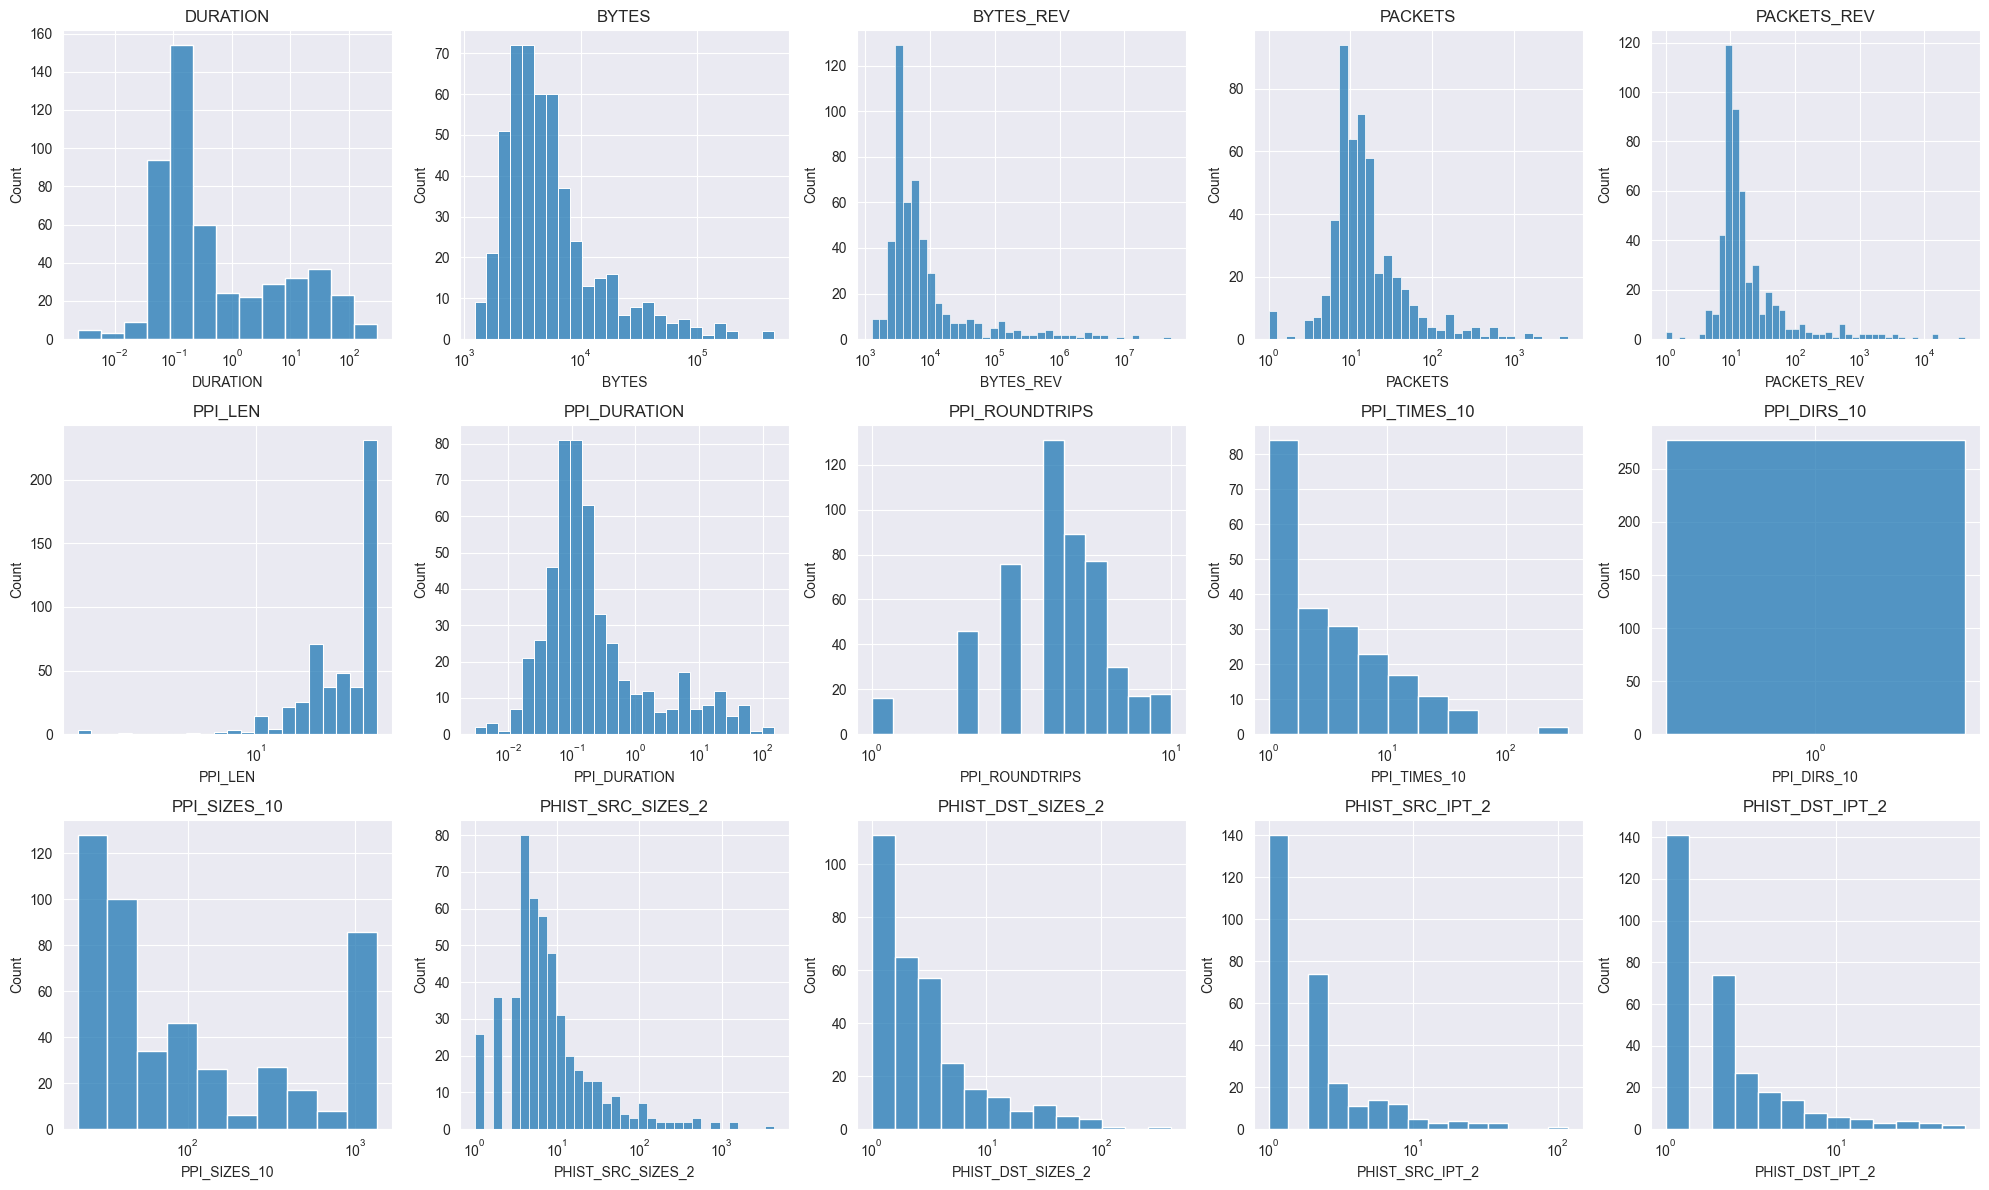

In [5]:
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns

ppi_sample_packet = math.floor(ppi_pad_len/3)
phist_sample_packet = math.floor(phist_pad_len/3)

numerical_cols = ['DURATION', 'BYTES', 'BYTES_REV', 'PACKETS', 'PACKETS_REV', 'PPI_LEN', 'PPI_DURATION', 'PPI_ROUNDTRIPS', f'PPI_TIMES_{ppi_sample_packet}', f'PPI_DIRS_{ppi_sample_packet}', f'PPI_SIZES_{ppi_sample_packet}', f'PHIST_SRC_SIZES_{phist_sample_packet}', f'PHIST_DST_SIZES_{phist_sample_packet}', f'PHIST_SRC_IPT_{phist_sample_packet}', f'PHIST_DST_IPT_{phist_sample_packet}']

fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(20, 12))
axes = axes.flatten()  # now just a flat list of 15 slots

for i, col in enumerate(numerical_cols):
    sns.histplot(week_1[col], kde=False, log_scale=True, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [6]:
from sklearn.preprocessing import LabelEncoder, RobustScaler

cols_to_robustscale = [col for col in week_1.columns.tolist() if week_1[col].dtype in ['int64', 'float64']]
cols_to_robustscale = [col for col in cols_to_robustscale if not col.startswith('PPI_DIRS')] #Removing PPI_DIR cols as they are already -1, 0 or 1

cols_to_label_encode = [col for col in week_1.columns.tolist() if week_1[col].dtype in ['str']]

ppi_dir_cols = [col for col in week_1.columns.tolist() if col.startswith('PPI_DIRS')]
ppi_dir_df = week_1[ppi_dir_cols]
bool_cols = [col for col in week_1.columns.tolist() if week_1[col].dtype in ['bool']]
bool_df = week_1[bool_cols]


def encode(col_names: list[str], scaler) -> pd.DataFrame:
    scaled_df = pd.DataFrame()
    for col in col_names:
        scaled = scaler.fit_transform(week_1[col])
        scaled_df[col] = scaled
    return scaled_df

encoders = set()
le = LabelEncoder()

encoded_df = encode(cols_to_label_encode, le)
encoders.add(le)

re = RobustScaler()
scaled_array = re.fit_transform(week_1[cols_to_robustscale])
scaled_df = pd.DataFrame(scaled_array, columns=cols_to_robustscale)
encoders.add(re)

final_df = pd.concat([encoded_df, scaled_df, ppi_dir_df, bool_df], axis=1)

final_df.to_csv('./post_processing_df.csv', index=True)